In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# loading text file as csv 
df=pd.read_csv(
    "SMSSpamCollection", # name of file 
    sep="\t" ,# colums are seprated by TAB
    header=None,
    names=["Label","Message"]
)
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

In [27]:
df

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [30]:
 #preprocessing the data 
  # Remobing punctuations, lowecase the text and stopwords

import re
import string

def preprocess(text):
    text=text.lower()
    text=re.sub(f'[{string.punctuation}]','',text)
    return text

df['Message']=df['Message'].apply(preprocess)

In [31]:
df

,Label,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
...,...,...
5567,1,this is the 2nd time we have tried 2 contact u...
5568,0,will ü b going to esplanade fr home
5569,0,pity was in mood for that soany other suggest...
5570,0,the guy did some bitching but i acted like id ...


In [39]:
# conerting text into numerical feature. because machine alony understand number not the engish words
from sklearn.feature_extraction.text  import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=3000)
x=vectorizer.fit_transform(df['Message']).toarray()
y=df["Label"].values

In [41]:
x,y


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([0, 0, 1, ..., 0, 0, 0], dtype=int64))

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train,Y_test=train_test_split(x,y, test_size=0.2, random_state=42)


In [53]:
from sklearn.svm import SVC
model=SVC(kernel='linear')
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

In [54]:
Y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [70]:
RBF_model=SVC(kernel='rbf')
RBF_model.fit(X_train,Y_train)

SVC()

In [71]:
RBF_pred=RBF_model.predict(X_test)

In [72]:
from  sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy=accuracy_score(Y_test,Y_pred)
report=classification_report(Y_test,Y_pred)
RBF_acc=accuracy_score(Y_test, RBF_pred)
RBF_report=classification_report(Y_test,RBF_pred)

In [75]:
print("Linear: ",accuracy," RBF: ",RBF_acc)
print("Linear: ",report,"\n RBF: ",RBF_report)

Linear:  0.9874439461883409  RBF:  0.9820627802690582
Linear:                precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115
 
 RBF:                precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



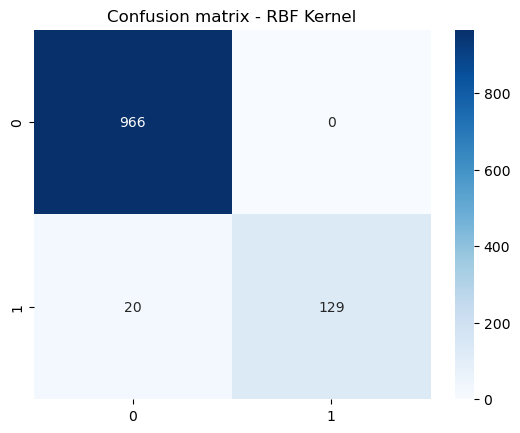

In [84]:
# visualize results
cm_linear=confusion_matrix(Y_test,RBF_pred)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix - RBF Kernel")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

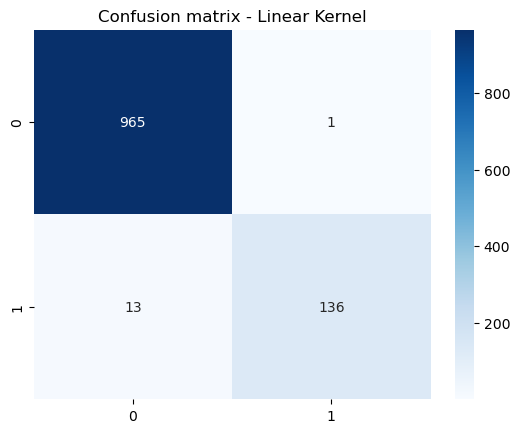

In [83]:
# visualize results
cm_linear=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix - Linear Kernel")
plt.show

In [85]:
def predict_email(text, model):
    text=preprocess(text)
    vector=vectorizer.transform([text]).toarray()
    prediction=model.predict(vector)[0]
    return "Spam" if prediction==1 else "Not Spam "

In [87]:
# Save model & vectorizer
import joblib
joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']